### 1. Import Packages

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load dataset

In [2]:
raw_data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
raw_data.head()

### 3. EDA

In [ ]:
raw_data.shape

In [90]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              7021 non-null   object 
 1   SeniorCitizen       7021 non-null   int64  
 2   Partner             7021 non-null   object 
 3   Dependents          7021 non-null   object 
 4   tenure              7021 non-null   int64  
 5   PhoneService        7021 non-null   object 
 6   MultipleLines       7021 non-null   object 
 7   InternetService     7021 non-null   object 
 8   OnlineSecurity      7021 non-null   object 
 9   OnlineBackup        7021 non-null   object 
 10  DeviceProtection    7021 non-null   object 
 11  TechSupport         7021 non-null   object 
 12  StreamingTV         7021 non-null   object 
 13  StreamingMovies     7021 non-null   object 
 14  Contract            7021 non-null   object 
 15  PaperlessBilling    7021 non-null   object 
 16  PaymentMeth

In [ ]:
raw_data.describe()

In [ ]:
raw_data.describe(include="object")

In [ ]:
raw_data.isnull().sum()

In [ ]:
sns.countplot(x="Churn", data=raw_data)

In [ ]:

sns.heatmap(data=raw_data.corr(numeric_only=True), cmap="coolwarm", annot=True, )

In [ ]:
sns.histplot(raw_data["MonthlyCharges"], kde=True)

In [ ]:
sns.boxplot(x=raw_data["MonthlyCharges"])

In [ ]:
sns.countplot(x="Contract", data=raw_data, hue="Churn")

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=raw_data)

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=raw_data)

In [ ]:
raw_data["Contract"].value_counts()

In [ ]:
pd.crosstab(raw_data["Contract"],
            raw_data["Churn"])

In [94]:
raw_data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
raw_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AveChargesPerMonth,IsNewUser
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5.Data cleaning

In [3]:
raw_data.shape

(7043, 21)

In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
raw_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
raw_data.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
raw_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

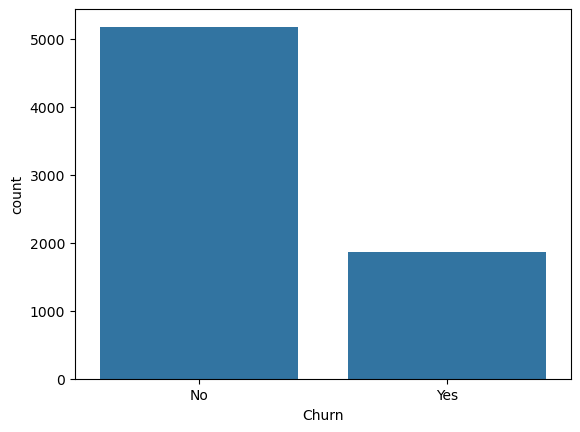

In [8]:
sns.countplot(x="Churn", data=raw_data)

<Axes: >

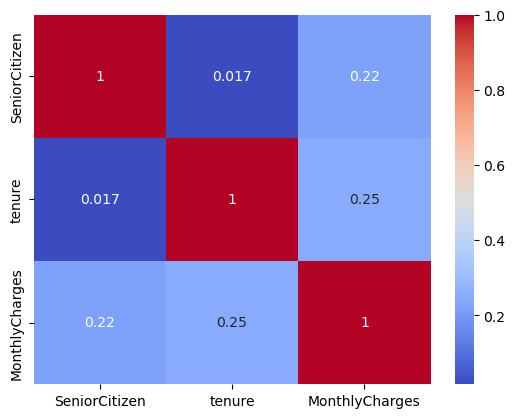

In [9]:

sns.heatmap(data=raw_data.corr(numeric_only=True), cmap="coolwarm", annot=True, )

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

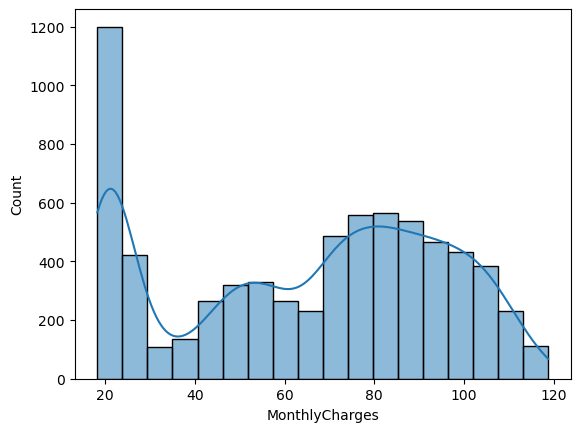

In [10]:
sns.histplot(raw_data["MonthlyCharges"], kde=True)

<Axes: xlabel='MonthlyCharges'>

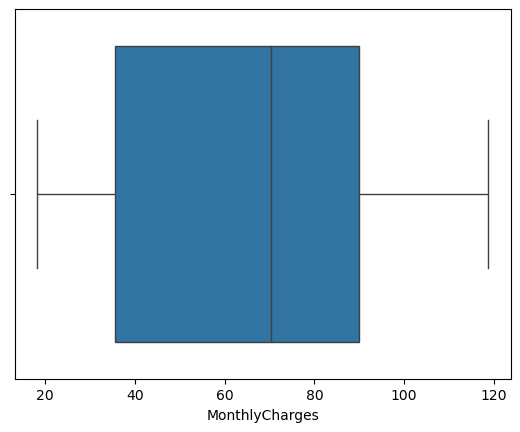

In [11]:
sns.boxplot(x=raw_data["MonthlyCharges"])

<Axes: xlabel='Contract', ylabel='count'>

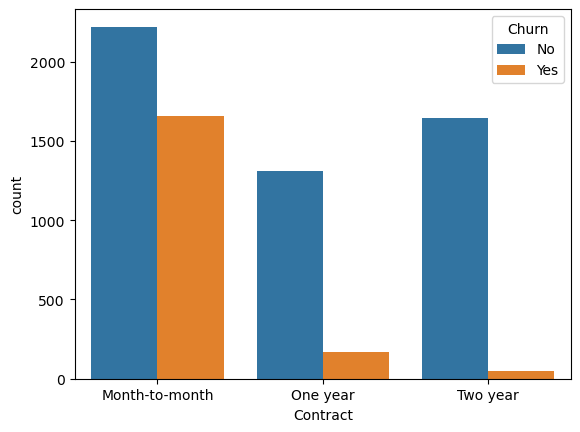

In [12]:
sns.countplot(x="Contract", data=raw_data, hue="Churn")

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

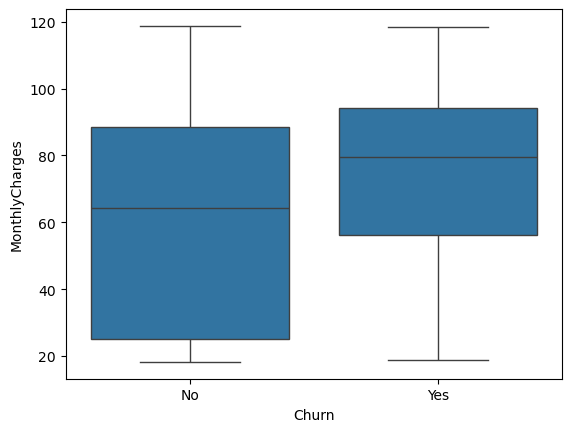

In [13]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=raw_data)

<Axes: xlabel='Churn', ylabel='tenure'>

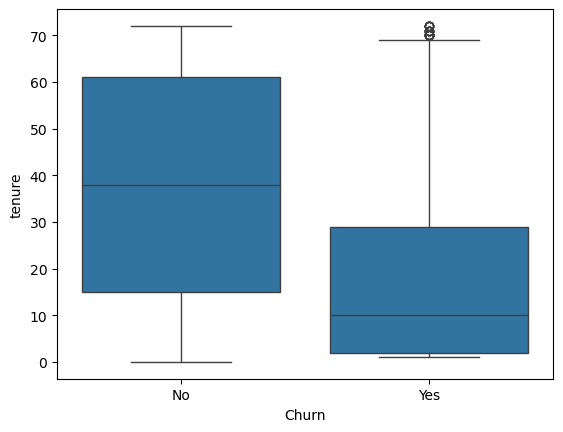

In [14]:
sns.boxplot(x="Churn", y="tenure", data=raw_data)

In [15]:
raw_data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [16]:
pd.crosstab(raw_data["Contract"],
            raw_data["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [17]:
raw_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5.Data cleaning

In [18]:
raw_data.drop(columns=["customerID"], inplace=True)

In [19]:
raw_data.duplicated().sum()

22

In [20]:
raw_data.drop_duplicates(inplace=True)

In [21]:
raw_data.shape

(7021, 20)

In [22]:
raw_data["TotalCharges"] = pd.to_numeric(raw_data["TotalCharges"],
                                         errors="coerce")

In [23]:
raw_data["TotalCharges"].dtype

dtype('float64')

In [24]:
raw_data["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [25]:
raw_data["Churn"].value_counts(normalize=True)*100

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

In [26]:
raw_data["Churn"] = raw_data["Churn"].map({
    "Yes": 1,
    "No": 0
})

### 4. Features Engineering

In [27]:
raw_data["AveChargesPerMonth"] = raw_data["TotalCharges"]/raw_data["tenure"].replace(0, 1)
raw_data["IsNewUser"] = (raw_data["tenure"]<12).astype(int)

### 5. Split data

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_dataset = raw_data.drop(["Churn"], axis=1)
y_dataset = raw_data["Churn"]

X_train, X, y_train, y = train_test_split(X_dataset, y_dataset, test_size=0.4)
X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size=0.5)

del X, y

### 6. Preprocessing pipeline

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [31]:
numerical_columns = ['tenure',
                     'MonthlyCharges', 
                     'TotalCharges',
                     'AveChargesPerMonth']

categorical_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'IsNewUser']

In [32]:
numerical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("numerical", numerical_pipe, numerical_columns), 
    ("cat", cat_pipe, categorical_columns)
])

### 7. train models

In [33]:
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score)


In [34]:
models = [LogisticRegression(random_state=42),
          DecisionTreeClassifier(random_state=42),
          RandomForestClassifier(random_state=42),
          GradientBoostingClassifier(random_state=42),
          AdaBoostClassifier(random_state=42),
          ExtraTreesClassifier(random_state=42),
          HistGradientBoostingClassifier(random_state=42),
          KNeighborsClassifier(),
          GaussianNB(),
          SVC(random_state=42),
          LGBMClassifier(random_state=42),
          CatBoostClassifier(random_state=42),
          XGBClassifier(random_state=42)]
pipelines = {}
results = []


In [35]:
for model in models:
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    pipelines[type(model).__name__] = pipeline 

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": type(model).__name__,
        "accuracy_score": accuracy_score(y_test, y_pred),
        "precision_score": precision_score(y_test, y_pred),
        "recall_score": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "roc_auc_score": roc_auc_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    })

d:\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1120, number of negative: 3092
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 4212, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265907 -> initscore=-1.015489
[LightGBM] [Info] Start training from score -1.015489
Learning rate set to 0.019037
0:	learn: 0.6795945	total: 126ms	remaining: 2m 6s
1:	learn: 0.6666464	total: 129ms	remaining: 1m 4s
2:	learn: 0.6544589	total: 132ms	remaining: 43.8s
3:	learn: 0.6444250	total: 133ms	remaining: 33.2s
4:	learn: 0.6340585	total: 135ms	remaining: 26.9s
5:	learn: 0.6239779	total: 138ms	remaining: 22.8s
6:	learn: 0.6134874	total: 140ms	remaining: 19.9s
7:	learn: 0.6061716	total: 142ms	remaining: 17.6s
8:	learn: 0.5971

In [36]:
results = pd.DataFrame(results)

In [37]:
results

,Model,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,classification_report
0,LogisticRegression,0.800000,0.668874,0.527415,0.589781,"[[922, 100], [181, 202]]",0.714784,precision recall f1-score ...
1,DecisionTreeClassifier,0.728114,0.501285,0.509138,0.505181,"[[828, 194], [188, 195]]",0.659657,precision recall f1-score ...
2,RandomForestClassifier,0.780783,0.632509,0.467363,0.537538,"[[918, 104], [204, 179]]",0.682801,precision recall f1-score ...
3,GradientBoostingClassifier,0.785765,0.631410,0.514360,0.566906,"[[907, 115], [186, 197]]",0.700918,precision recall f1-score ...
4,AdaBoostClassifier,0.790747,0.643087,0.522193,0.576369,"[[911, 111], [183, 200]]",0.706791,precision recall f1-score ...
5,ExtraTreesClassifier,0.764413,0.586093,0.462141,0.516788,"[[897, 125], [206, 177]]",0.669916,precision recall f1-score ...
6,HistGradientBoostingClassifier,0.790747,0.646865,0.511749,0.571429,"[[915, 107], [187, 196]]",0.703526,precision recall f1-score ...
7,KNeighborsClassifier,0.757295,0.555851,0.545692,0.550725,"[[855, 167], [174, 209]]",0.691143,precision recall f1-score ...
8,GaussianNB,0.687544,0.459654,0.832898,0.592386,"[[647, 375], [64, 319]]",0.732985,precision recall f1-score ...
9,SVC,0.798577,0.692308,0.469974,0.559876,"[[942, 80], [203, 180]]",0.695848,precision recall f1-score ...


### 8. hyperparameters tuning optuna

In [38]:
import optuna
from sklearn.model_selection import cross_val_score

In [39]:
def xgb_params(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }
    return params 

In [45]:
def objective(trial, model_class, params_func):
    params = params_func(trial)
    model = Pipeline([
        ("preprocess", preprocess),
        ("model", model_class(**params, random_state=42))
    ])

    score = cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()
    return score 

In [46]:
study = optuna.create_study(direction="maximize")

study.optimize(
    lambda trial:
        objective(
            trial, XGBClassifier, xgb_params ),
    n_trials=50
)

[I 2026-08-01 22:08:32,138] A new study created in memory with name: no-name-8e70ccc7-a7b4-481e-9839-72f675f37356
[I 2026-08-01 22:08:34,222] Trial 0 finished with value: 0.5447097020542979 and parameters: {'n_estimators': 469, 'max_depth': 8, 'learning_rate': 0.22605962283078382, 'subsample': 0.6234780607313022, 'colsample_bytree': 0.9893439859150309}. Best is trial 0 with value: 0.5447097020542979.
[I 2026-08-01 22:08:35,759] Trial 1 finished with value: 0.5640646738142078 and parameters: {'n_estimators': 264, 'max_depth': 10, 'learning_rate': 0.0683491812838281, 'subsample': 0.607174992376565, 'colsample_bytree': 0.676836702545422}. Best is trial 1 with value: 0.5640646738142078.
[I 2026-08-01 22:08:36,367] Trial 2 finished with value: 0.5712806406434098 and parameters: {'n_estimators': 187, 'max_depth': 4, 'learning_rate': 0.26718220011129906, 'subsample': 0.7270387770432172, 'colsample_bytree': 0.6182379079878374}. Best is trial 2 with value: 0.5712806406434098.
[I 2026-08-01 22:0

In [47]:
study.best_value

0.6017151703291401

In [49]:
best_model = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(**study.best_params, random_state=42))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AveChargesPerMonth']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.03420041954123414, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=167,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [50]:
y_pred = best_model.predict(X_test)

In [51]:
confusion_matrix(y_test, y_pred)

array([[917, 105],
       [185, 198]], dtype=int64)

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1022
           1       0.65      0.52      0.58       383

    accuracy                           0.79      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.78      0.79      0.79      1405



### 9. model evaluation

In [55]:
y_predict = best_model.predict(X_cv)

print(classification_report(y_cv, y_predict))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1050
           1       0.63      0.57      0.60       354

    accuracy                           0.81      1404
   macro avg       0.74      0.73      0.74      1404
weighted avg       0.80      0.81      0.80      1404



### 10. features importance

<Figure size 1000x800 with 0 Axes>

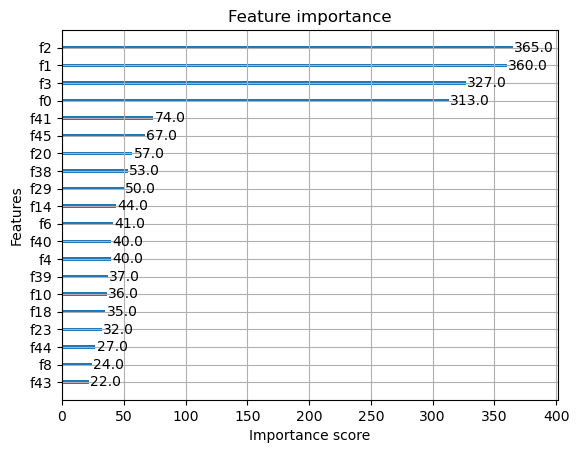

In [56]:
from xgboost import plot_importance

xgb_model = best_model.named_steps["model"]

plt.figure(figsize=(10,8))
plot_importance(xgb_model, max_num_features=20)
plt.show()

In [58]:
import shap 

xgb_model = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

X_train_processed = best_model.named_steps["preprocess"].transform(X_train)
X_test_processed = best_model.named_steps["preprocess"].transform(X_test)

In [60]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)

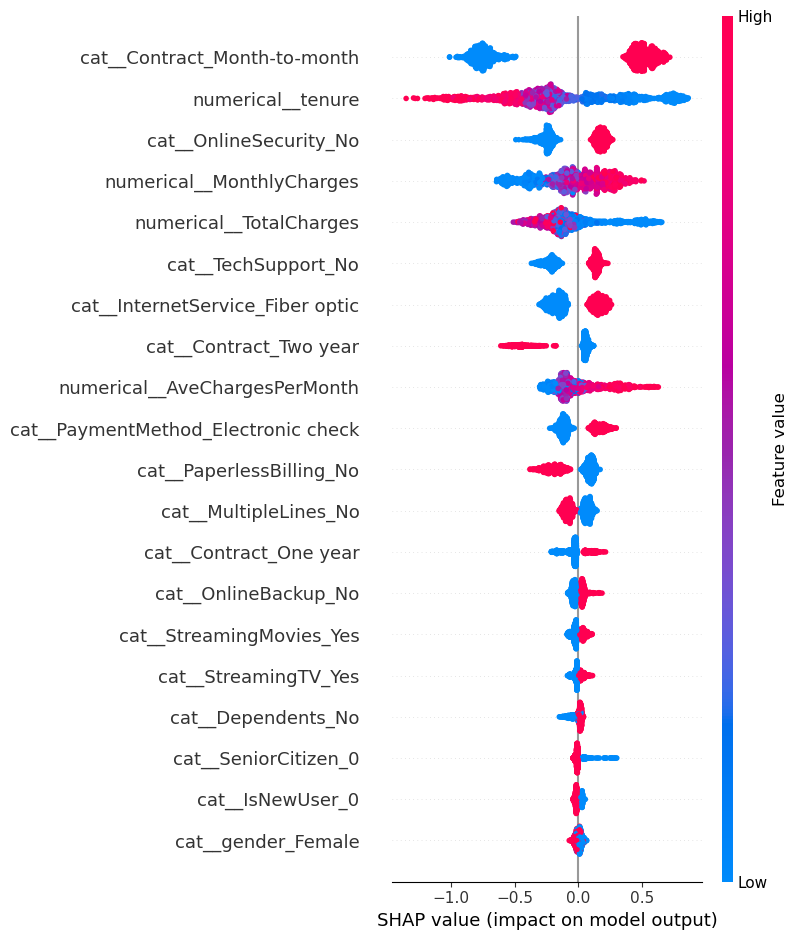

In [61]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

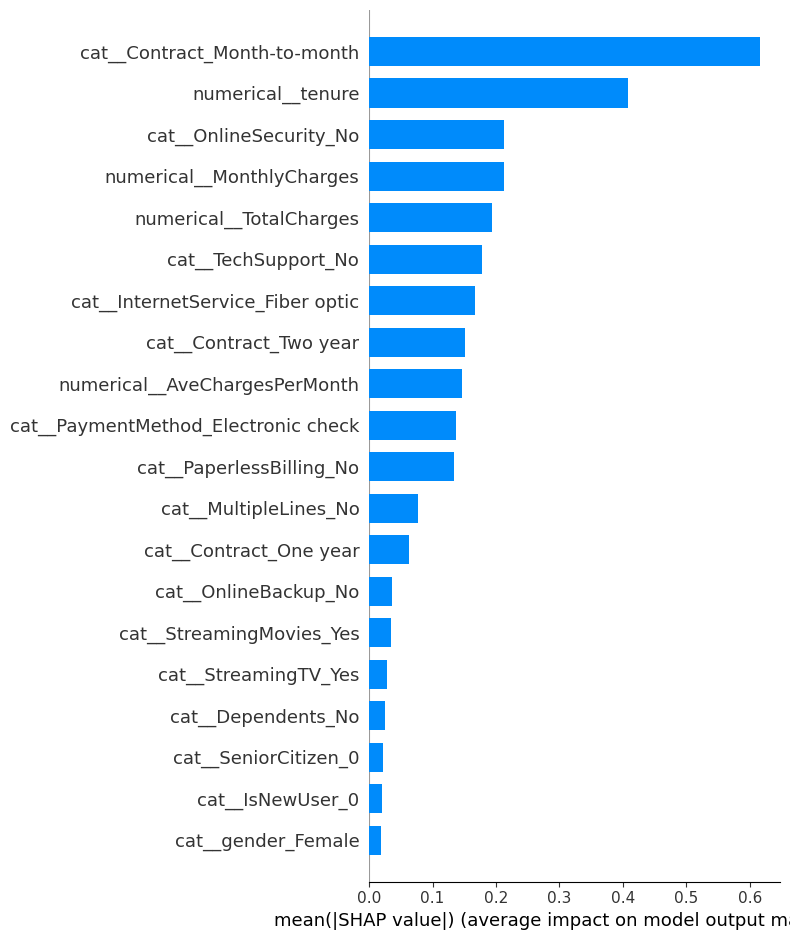

In [62]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

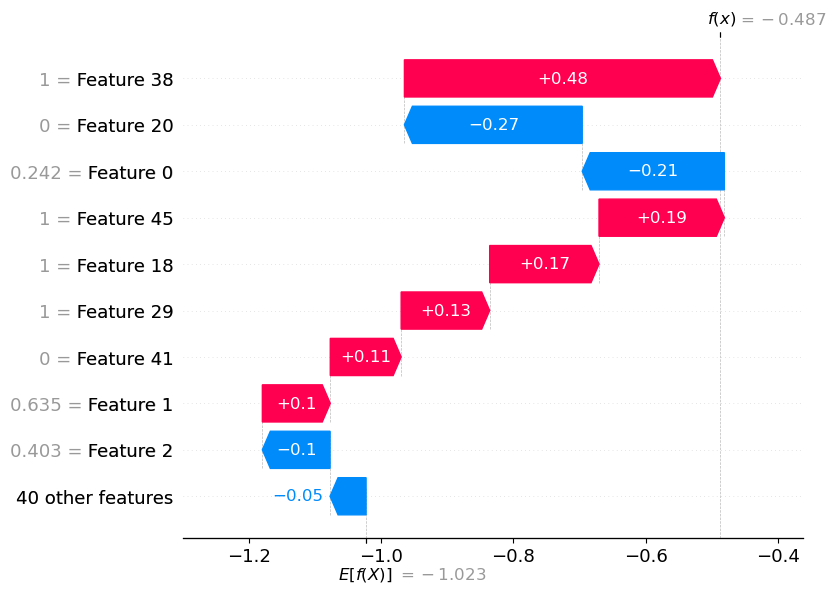

In [66]:
shap.waterfall_plot(
    explainer(X_test_processed[0:1])[0]
)

### 11. save the model

In [67]:
import joblib 
joblib.dump(best_model, "../models/xgb_pipeline.pkl")

['../models/xgb_pipeline.pkl']

### 12. load and predict

In [72]:
import joblib
model = joblib.load("../models/xgb_pipeline.pkl")

x_cv_data = X_cv.iloc[[0]]
print(f"The Churn is : {"YES" if model.predict(x_cv_data)[0] == 1 else "NO"}")

The Churn is : YES
